<h1 style="color: green;">Home task : Pytorch</h1>

In [295]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
import random


## Load data Sign Language MNIST


In [237]:
train_df = pd.read_csv('/Users/user/Desktop/Camp2025/lesson_24/data/sign_mnist_train/sign_mnist_train.csv')
test_df = pd.read_csv('/Users/user/Desktop/Camp2025/lesson_24/data/sign_mnist_test/sign_mnist_test.csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train labels:", sorted(train_df['label'].unique()))
print("Test labels:", sorted(test_df['label'].unique()))
print("Missing values:", train_df.isnull().sum().sum() + test_df.isnull().sum().sum())


Train shape: (27455, 785)
Test shape: (7172, 785)
Train labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Test labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
Missing values: 0


In [238]:
def fix_labels(df):
    df['label'] = df['label'].apply(lambda x: x if x < 9 else x - 1)
    return df

train_df = fix_labels(train_df)
test_df = fix_labels(test_df)


## Transformations and division

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data, val_data = train_test_split(train_df, test_size=0.2, random_state=42)

In [240]:
class SignLanguageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        label = self.dataframe.iloc[idx, 0]
        image = np.array(self.dataframe.iloc[idx, 1:], dtype=np.uint8).reshape((28, 28))
        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        return image, label


In [241]:
batch_size = 64

train_dataset = SignLanguageDataset(train_data, transform=transform)
test_dataset = SignLanguageDataset(test_df, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


len(train_dataset), len(test_dataset)

(21964, 7172)

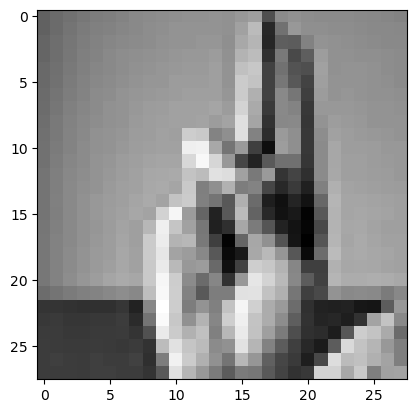

In [242]:
image, label = next(iter(train_loader))
plt.imshow(image[0].squeeze(), cmap='gray')
plt.show()

## Model

In [244]:
class SignLanguageModel(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, output_size),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [245]:
input_size = torch.numel(train_dataset[0][0])

output_size = len(train_df.label.unique()) 

loss_fn = nn.CrossEntropyLoss()


## Training model

In [246]:
def train_loop(dataloader, model, criterion, optimizer, epoch):
    model.train()
    total_loss = 0.0
    num_batches = len(dataloader)


    tqdm_loader = tqdm(dataloader, unit="batch",
                       desc=f"Epoch {epoch}", total=len(dataloader))
    for batch, (X, y) in enumerate(tqdm_loader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item()


        if batch % 1000 == 0:
            tqdm_loader.set_postfix(loss=loss.item())
            
    average_loss = total_loss / num_batches
    return average_loss


def test_loop(dataloader, model, criterion):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += criterion(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    accuracy = 100 * correct

    print(
        f"Test Error: \n Accuracy: {accuracy:.1f}%, Avg loss: {test_loss:.8f} \n")

    return test_loss, accuracy


In [ ]:
learning_rate = 0.001

epochs = 15

loss = nn.CrossEntropyLoss()
model = SignLanguageModel(input_size=input_size, output_size=output_size).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

acc_history = []
loss_history = []

for t in range(epochs):
    ep_loss = train_loop(train_loader, model, loss, optimizer, epoch=t)
    ep_test_loss, ep_acc = test_loop(test_loader, model, loss)
    acc_history.append(ep_acc)
    loss_history.append(ep_loss)

Epoch 0: 100%|██████████████████| 344/344 [00:16<00:00, 20.25batch/s, loss=3.17]


Test Error: 
 Accuracy: 61.5%, Avg loss: 1.23641770 



Epoch 1: 100%|█████████████████| 344/344 [00:19<00:00, 17.68batch/s, loss=0.803]


Test Error: 
 Accuracy: 70.0%, Avg loss: 0.96550695 



Epoch 2: 100%|█████████████████| 344/344 [00:19<00:00, 17.94batch/s, loss=0.246]


...

Test Error: 
 Accuracy: 76.9%, Avg loss: 1.14130917 



Epoch 13: 100%|██████████████| 344/344 [00:19<00:00, 17.96batch/s, loss=0.00215]


Test Error: 
 Accuracy: 77.1%, Avg loss: 1.14969281 



Epoch 14: 100%|███████████████| 344/344 [00:19<00:00, 17.25batch/s, loss=0.0028]


Test Error: 
 Accuracy: 76.5%, Avg loss: 1.17708976 



In [310]:
torch.save(model, 'mymodel.pth')
loaded_model = torch.load('mymodel.pth').to(device)
acc_history, loss_history

([61.54489682097044,
  69.98047964305633,
  73.80089235917457,
  76.99386503067484,
  76.2409369771333,
  76.81260457334076,
  76.82654768544339,
  76.19910764082543,
  76.54768544339096,
  76.58951477969883,
  76.92414947016174,
  76.81260457334076,
  76.86837702175126,
  77.10540992749581,
  76.53374233128835],
 [1.9353223604171774,
  0.5273150782165832,
  0.15810572258521652,
  0.0518333547705308,
  0.024487693344654386,
  0.014727532384418991,
  0.010385161674538151,
  0.00793930069613812,
  0.006322343336948908,
  0.005233776649368147,
  0.004448687331818672,
  0.0038445464878202264,
  0.003375161420905876,
  0.0029909743471910398,
  0.002697270445127668])

## Accuracy and loss graphs by epoch

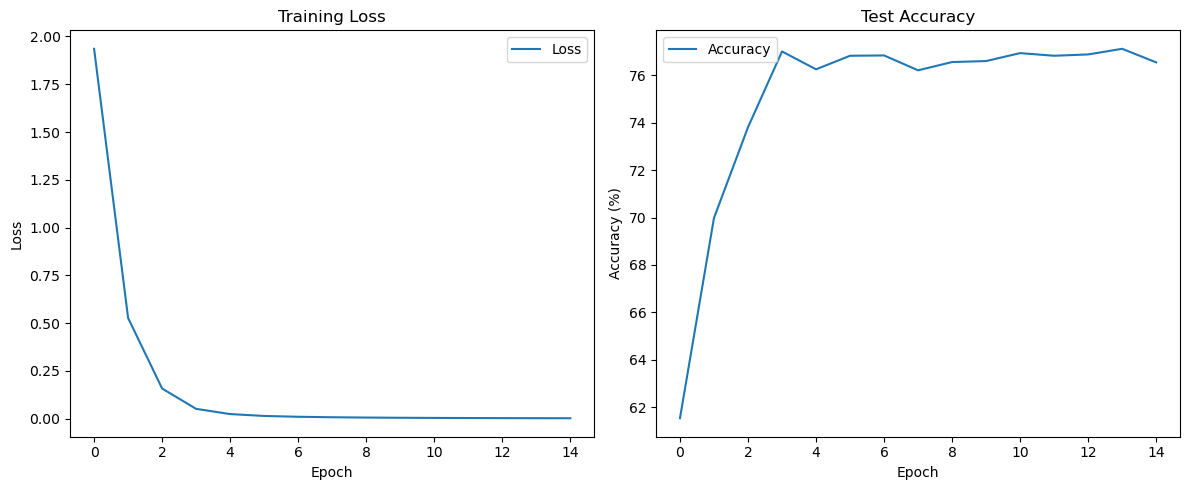

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history, label="Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(acc_history, label="Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Visualize 10 random elements from test set

Real: 7 Predicted: 7


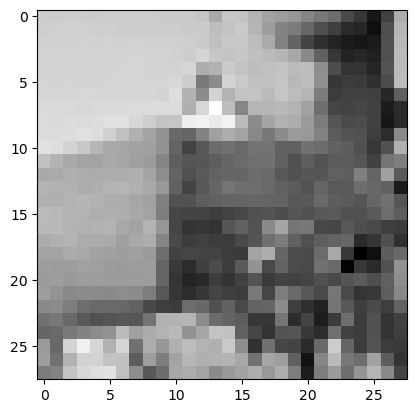

Real: 10 Predicted: 10


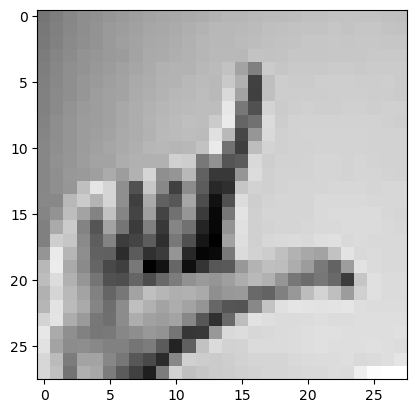

Real: 20 Predicted: 21


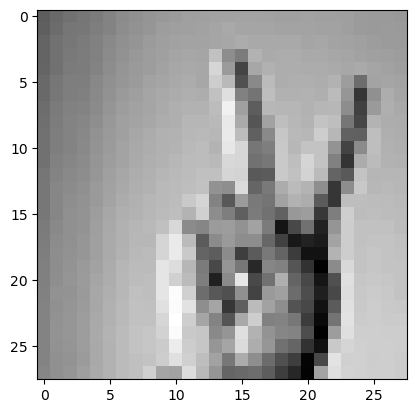

Real: 19 Predicted: 9


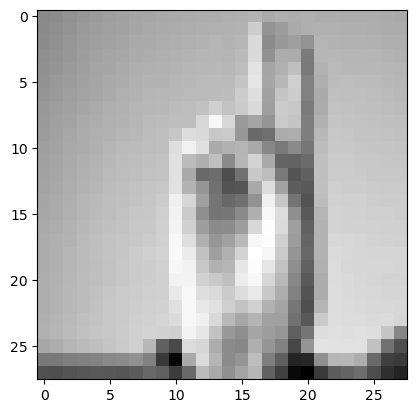

Real: 3 Predicted: 3


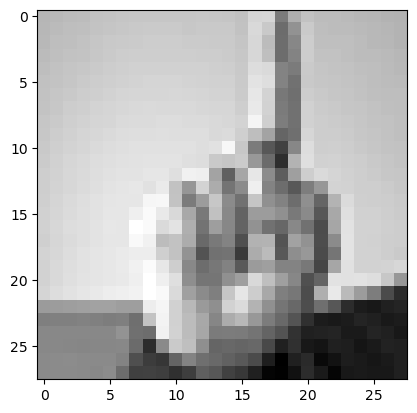

Real: 15 Predicted: 15


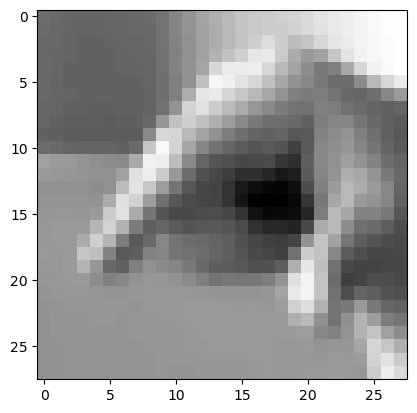

Real: 18 Predicted: 18


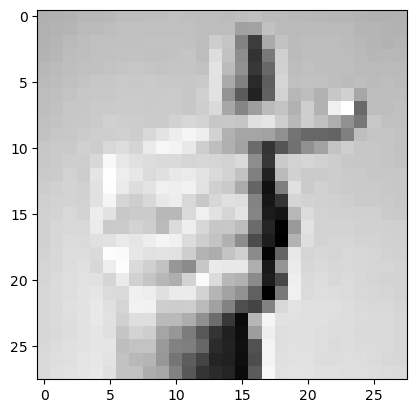

Real: 1 Predicted: 1


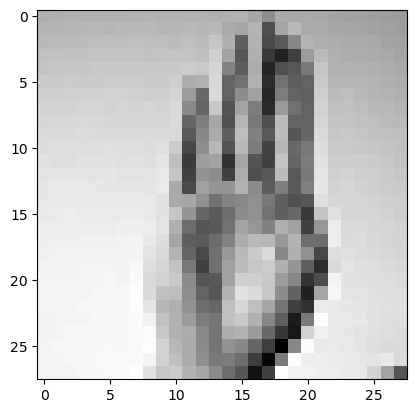

Real: 20 Predicted: 21


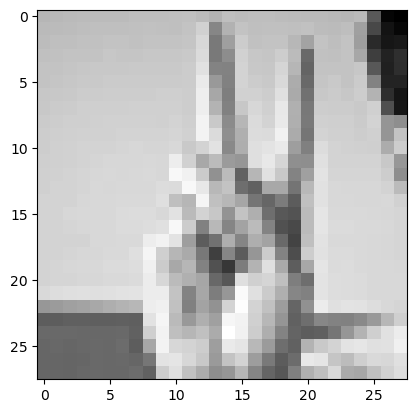

Real: 3 Predicted: 3


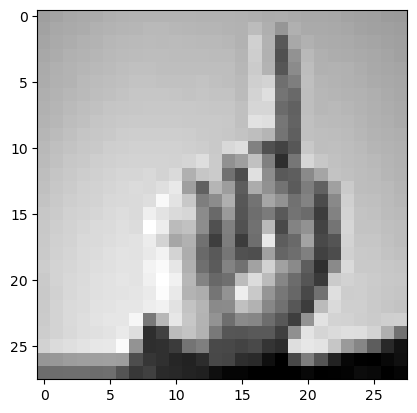

In [ ]:
num_samples = 10
random_indices = random.sample(range(len(test_dataset)), num_samples)


images = []
labels = []
model.eval()

with torch.no_grad():
    for idx in random_indices:
        image, true_label = test_dataset[idx]
        image_tensor = image.unsqueeze(0).to(device)
        prediction = model(image_tensor)
        predicted_label = prediction.argmax(1).item()
        
        images.append(image)
        labels.append({'real': true_label, 'predicted': predicted_label})

for image, label in zip(images, labels):
    print(f'Real: {label["real"]} Predicted: {label["predicted"]}')
    plt.imshow(image.squeeze(), cmap='gray')
    plt.show()

# Conclusions

I developed a custom neural network model using the PyTorch libary and applied it to the "Sign Language MNIST" dataset
During training, I visualized the model's performance by plotting the training and validation loss and accuracy across all epochs. These graphs clearly show how the model improved over time, helping to understand the learning dynamics and detect overfitting or underfitting.
Finally, Was selected 10 random images from the test dataset and displayed both the actual and predicted labels for these images. This allowed me to qualitatively evaluate how well the model generalizes to unseen data and visually confirm correct or incorrect classifications.